# seege_ usage tutorial 
for synthetic EEG evaluation

#### 1. Imports and basic setup

In [8]:
import pickle
from preprocessing import *
from amplitude_fidelity import *
from frequency_fidelity import *
from time_frequency_fidelity import *
from complexity_fidelity import *
from time_fidelity import *
from diversity2 import *
from privacy import *
import evaluation_score
from itertools import product
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3), dpi=100)
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)

<Figure size 600x300 with 0 Axes>

#### 2. Data preprocessing

1. Load data
2. Downsampling
3. Normalization

#### 2.1. Load data

(1000, 1536)
(1000, 1536)


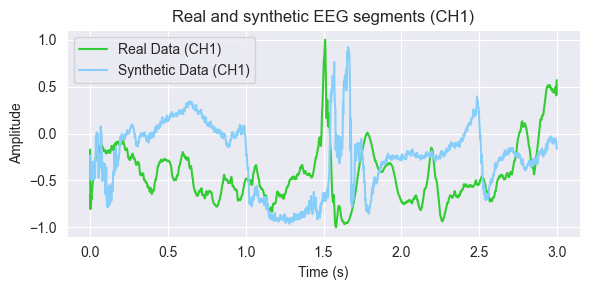

In [3]:
real_data = load_pickle("/Users/is/PycharmProjects/seege/mayo_epileptic_1000seg.pkl")
synthetic_data = load_pickle("/Users/is/PycharmProjects/seege/synthetic_mayo_epileptic_1000seg.pkl")

# Print data shape
print(np.shape(real_data)) #(5, 20, 1563) 5 samples of 20 channels 3s at 512Hz
print(np.shape(synthetic_data))

# This evaluation is for sparse signals, assumes shape (n_samples, n_points)
real_seg = real_data[4]         # shape (20, 1536)
synth_seg = synthetic_data[4]   # shape (20, 1536)

t = np.arange(len(real_seg)) / 512  # Time vector in seconds
plt.figure(figsize=(6, 3), facecolor=plt.rcParams['figure.facecolor'])

ax = sns.lineplot(
    x=t,
    y=real_seg,
    color="limegreen",
    label="Real Data (CH1)"
)

sns.lineplot(
    x=t,
    y=synth_seg,
    color="lightskyblue",
    label="Synthetic Data (CH1)",
    ax=ax
)

ax.set_title("Real and synthetic EEG segments (CH1)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.legend()
plt.tight_layout()
plt.show()


#### 3. Fidelity evaluation


#### 3.1. Time fidelity

=== Mean Hjorth Parameters ===
Real Signals: Activity=0.1111, Mobility=0.0778, Complexity=9.4033
Synthetic Signals: Activity=0.1268, Mobility=0.2156, Complexity=8.3408
=== Hjorth Parameters Summary ===
Activity - Wasserstein Distance (R-S): 0.0157
Mobility - Wasserstein Distance (R-S): 0.1378
Complexity - Wasserstein Distance (R-S): 1.1440
Activity - Wasserstein Distance Normalized (R-S): 0.3472
Mobility - Wasserstein Distance Normalized (R-S): 6.0027
Complexity - Wasserstein Distance Normalized (R-S): 0.2945
Activity mean relative diff: 14.2% (synthetic vs real)
Mobility mean relative diff: 177.1% (synthetic vs real)
Complexity mean relative diff: -11.3% (synthetic vs real)
Average Wasserstein Distance Normalized: 2.2148
Average Wasserstein Distance: 0.4325
Mahalanobis Distance: 1.6885 Approx. p-value (χ², df=3): 0.4151



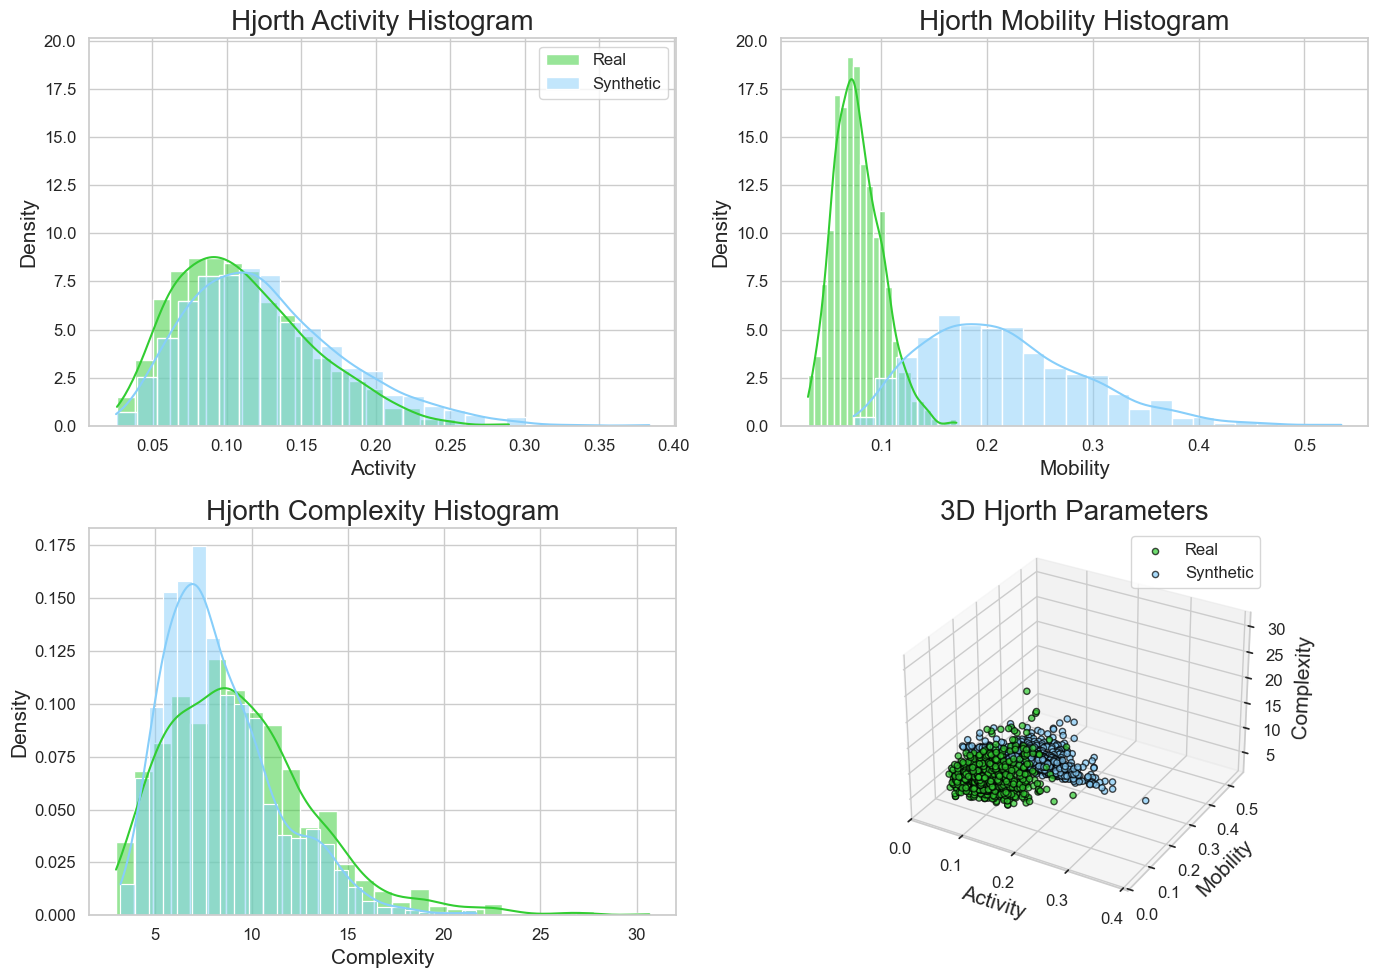

Time Fidelity Score  : 0.507
Time Fidelity Components:
  Activity   (norm WD): 0.742
  Mobility   (norm WD): 0.143
  Complexity (norm WD): 0.772
  Mahalanobis        : 0.372


0.5073747785180781

In [4]:
# Initialize class
sim = TimeFidelity()

# Compute Hjorth metrics
hjorth_dataset = sim.compute_hjorth_metrics(real_data, synthetic_data, verbose=True)

# Plot Hjorth metrics
hjorth_figures = sim.plot_hjorth_metrics(real_data, synthetic_data)

# Compute time fidelity score
evaluation_score.compute_time_fidelity_score(real_data, synthetic_data)

#### 3.2. Frequency fidelity

Relative Bands Power (Dataset):
  Delta: Real: 53.17%, Synthetic: 61.88%, Diff: 8.71%
  Theta: Real: 16.81%, Synthetic: 12.61%, Diff: 4.20%
  Alpha: Real: 6.21%, Synthetic: 5.01%, Diff: 1.20%
  Beta: Real: 6.35%, Synthetic: 5.21%, Diff: 1.14%
  Gamma: Real: 0.98%, Synthetic: 1.05%, Diff: 0.06%
  Ripple: Real: 0.06%, Synthetic: 1.18%, Diff: 1.12%
  Fast Ripple: Real: 0.00%, Synthetic: 0.04%, Diff: 0.04%
Statistical Test Results (Dataset):
  Delta: Wilcoxon | p=< 0.001 (exact=3.00e-37) | significant difference | Cohen's d=-0.447
  Theta: Wilcoxon | p=< 0.001 (exact=9.29e-40) | significant difference | Cohen's d=0.459
  Alpha: Wilcoxon | p=< 0.001 (exact=3.75e-13) | significant difference | Cohen's d=0.227
  Beta: Wilcoxon | p=< 0.001 (exact=1.95e-06) | significant difference | Cohen's d=0.171
  Gamma: Wilcoxon | p=< 0.001 (exact=2.46e-04) | significant difference | Cohen's d=-0.058
  Ripple: Wilcoxon | p=< 0.001 (exact=8.53e-165) | significant difference | Cohen's d=-1.641
  Fast Ripple:

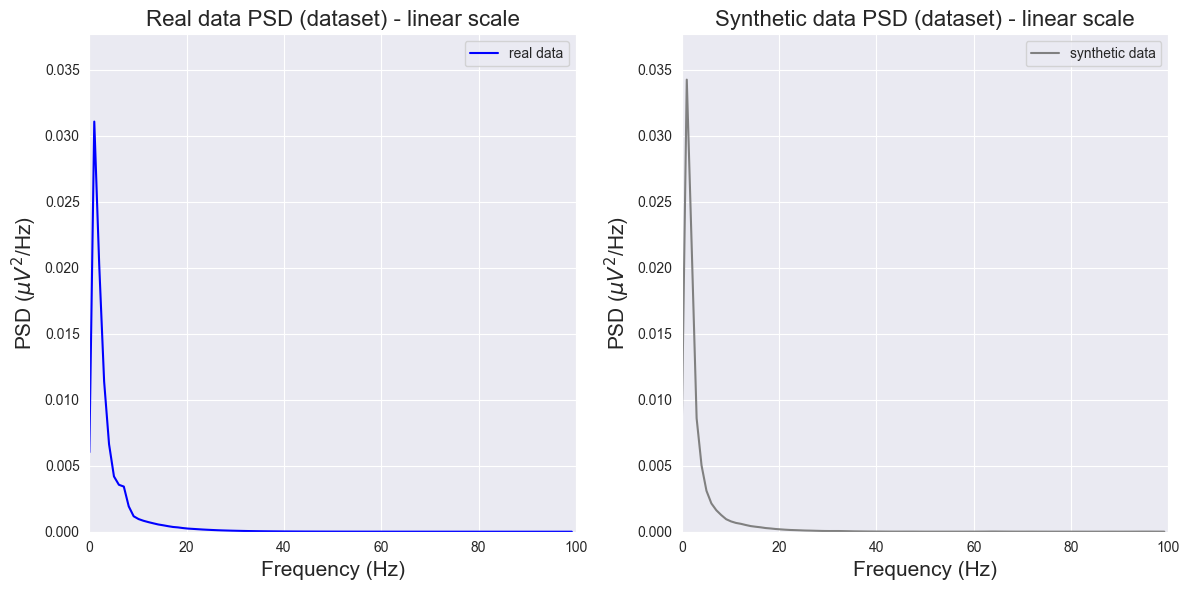

Frequency Fidelity Score: 0.61


In [4]:
# Initialize class
frequency_analysis = FrequencyFidelity(fs=512)
# Compute frequency similarity metrics
# At dataset level
frequency_analysis.compare_relative_power(real_data, synthetic_data)
frequency_analysis.spectral_coherence(real_data, synthetic_data)
# At sample level
#frequency_analysis.compare_relative_power(real_data[0], synthetic_data[0])
#frequency_analysis.spectral_coherence(real_data[0], synthetic_data[0])

#Plot average PSD
# At dataset level
frequency_analysis.plot_psd(real_data, synthetic_data, scale="linear")
# At sample level
#frequency_analysis.plot_psd(real_data[5], synthetic_data[5], scale="log")

# Compute frequency fidelity score
# At dataset level
evaluation_score.compute_frequency_fidelity_score(real_data, synthetic_data, fs=512)
# At sample level
#evaluation_score.compute_frequency_fidelity_score(real_data[0], synthetic_data[0], fs=512)

#### 3.3. Time-frequency fidelity

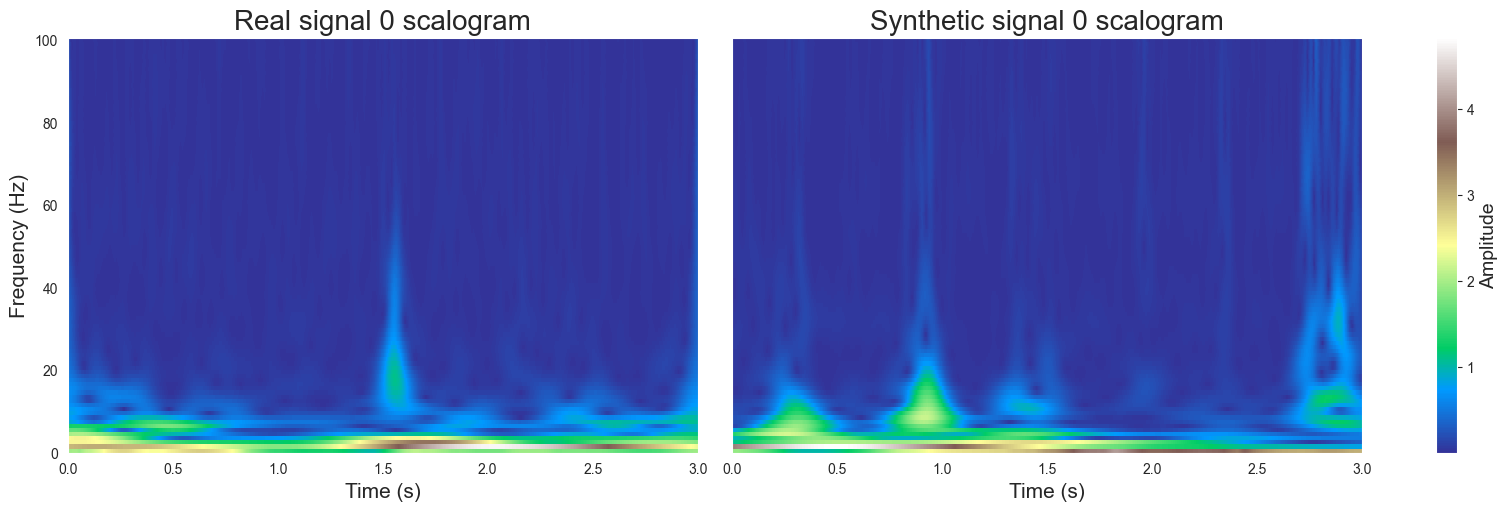

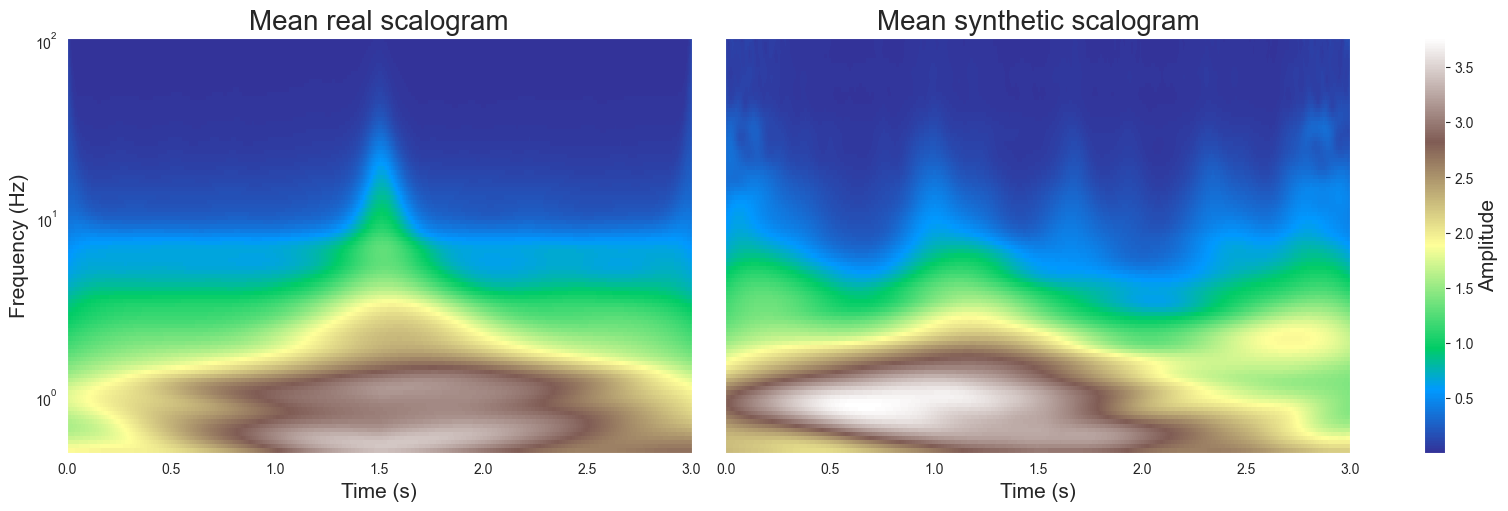

RR  | SSIM = 0.878 ± 0.0302 | NRMSE = 0.0634 ± 0.0144 | Cosine = 0.791 ± 0.0838 | mode: all_vs_all, pairs: 4950 (dataset)
RS  | SSIM = 0.834 ± 0.0342 | NRMSE = 0.0761 ± 0.0138 | Cosine = 0.717 ± 0.0802 | mode: all_vs_all, pairs: 10000 (dataset)
SS  | SSIM = 0.818 ± 0.0329 | NRMSE = 0.0737 ± 0.013 | Cosine = 0.759 ± 0.0732 | mode: all_vs_all, pairs: 4950 (dataset)

=== Burst Statistics Summary ===
Band: 13–30 Hz | Threshold: percentile (p=75) | min_dur=100.0 ms | merge_gap=50.0 ms | smooth=50.0 ms
N_real=100 | N_synth=100

Feature                 R_mean      S_mean    RS WD(z)      RR rSD      SS rSD
------------------------------------------------------------------------------
n_bursts                   2.6        3.12        0.66        1.48        1.48
rate_hz                  0.867        1.04        0.66       0.494       0.494
mean_dur_s               0.258        0.23       0.286      0.0586       0.049
median_dur_s             0.247       0.223       0.291      0.0854      0.048

In [4]:
# Initialize class
time_frequency_analysis = TimeFrequencyFidelity(fs=512)

# Plot scalograms
# At sample level
time_frequency_analysis.plot_scalograms(real_data, synthetic_data, signal_index_real=0, signal_index_synth=0)
# At dataset level
time_frequency_analysis.plot_mean_scalograms(real_data,synthetic_data, freq_scale="log")

# Compute time-frequency similarity metrics
# At dataset level
time_frequency_analysis.compute_scalogram_similarity_metrics(real_data[:100],synthetic_data[:100])
# At sample level
#time_frequency_analysis.compute_scalogram_similarity_metrics(real_data[0], synthetic_data[0])

# Compute burst statistics within the beta band
burst_results = time_frequency_analysis.compute_burst_statistics(real_data[:100], synthetic_data[:100], band=(13, 30))

# Compute time-frequency fidelity score
#evaluation_score.compute_time_frequency_fidelity_score(real_data[1], synthetic_data[3], fs=512)
evaluation_score.compute_time_frequency_fidelity_score(real_data[:100], synthetic_data[:100], fs=512, mode="all_vs_all")


#### 3.4. Complexity fidelity


MFDCCA Cross-Hurst Exponent (avg H(q)):
  real vs real:        1.3982 ± 0.0516
  real vs synthetic:   1.3375 ± 0.0675
  synthetic vs synthetic: 1.2916 ± 0.0883

MFDCCA Cross-Fluctuation F_xy(q) [averaged]:
  real vs real:        0.4383 ± 0.0753
  real vs synthetic:   0.3669 ± 0.0561
  synthetic vs synthetic: 0.3352 ± 0.0526

MFDCCA Width of Singularity Spectrum (Δα):
  real vs real:        0.9875 ± 0.1929
  real vs synthetic:   0.7079 ± 0.1837
  synthetic vs synthetic: 0.3415 ± 0.1489

MFDCCA Cross-Correlation Ratio p(q) [averaged over q]:
  real vs real:        1.0083 ± 0.0329
  real vs synthetic:   0.9486 ± 0.0266
  synthetic vs synthetic: 0.9099 ± 0.0206

MFDCCA Hurst Exponent:
  real vs real: Mean = 1.3982, Std = 0.0516
  real vs synthetic: Mean = 1.3375, Std = 0.0675
  synthetic vs synthetic: Mean = 1.2916, Std = 0.0883


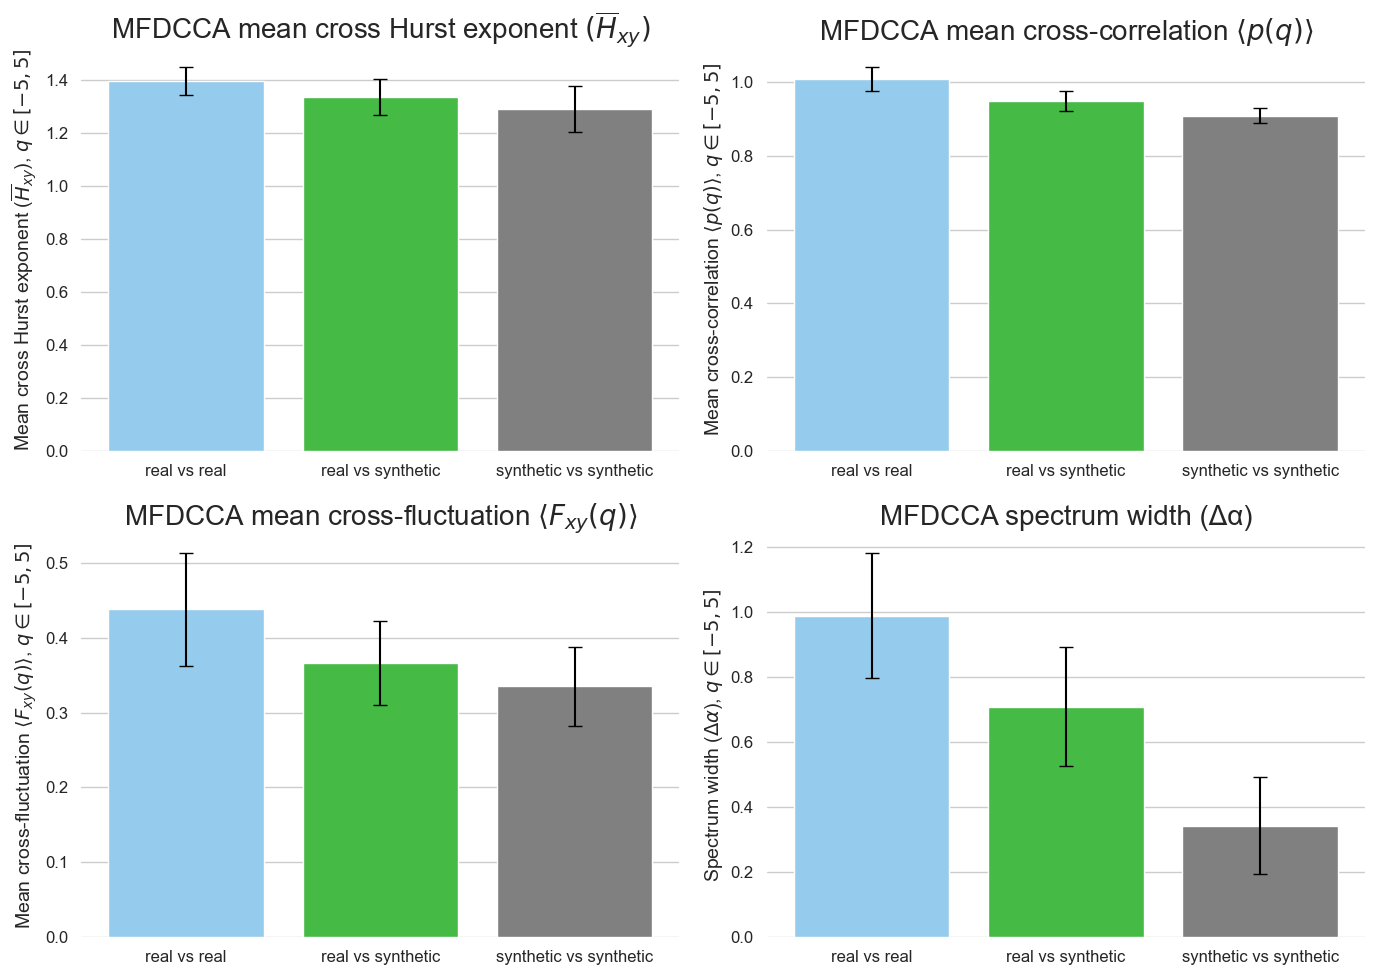

=== Entropy metrics ===
Wasserstein Distances (lower = more similar):
  SampEn WD: 0.423
  PermEn WD: 0.3784
  LZC   WD: 0.175
Means (Real vs Synthetic):
  SampEn: 0.3593 vs 0.7824
  PermEn: 0.612 vs 0.9904
  LZC   : 0.2157 vs 0.3907


DCCA Hurst Exponent (Hxy):
  real vs real: 1.2249 ± 0.0421
  real vs synthetic: 1.2402 ± 0.0706
  synthetic vs synthetic: 1.2701 ± 0.0993

DCCA Cross-Correlation Coefficient (ρ) :
  real vs real: 0.5058 ± 0.1528
  real vs synthetic: 0.0016 ± 0.0857
  synthetic vs synthetic: 0.2437 ± 0.2359

MFDFA Hurst Exponent:
  real: Mean = 1.6027, Std = 0.5585
  synthetic: Mean = 1.2922, Std = 0.1911

MFDCCA Cross-Hurst Exponent (avg H(q)):
  real vs real:        1.3982 ± 0.0516
  real vs synthetic:   1.3375 ± 0.0675
  synthetic vs synthetic: 1.2916 ± 0.0883

MFDCCA Cross-Fluctuation F_xy(q) [averaged]:
  real vs real:        0.4383 ± 0.0753
  real vs synthetic:   0.3669 ± 0.0561
  synthetic vs synthetic: 0.3352 ± 0.0526

MFDCCA Width of Singularity Spectrum (Δα):
  

In [7]:
# Initialize class for MFDCCA method (for DCCA and MFDFA, specify method accordingly)
cf = ComplexityFidelity(real_seg, synth_seg, method='MFDCCA')

# Compute MFDCCA metrics
cf.compute_fractal_metrics()

# Plot MFDCCA metrics
cf.plot_metrics()

# Compute entropy metrics
entropy_metrics = cf.compute_entropy_complexity_metrics(real_seg, synth_seg)

# Compute complexity fidelity score
evaluation_score.compute_complexity_fidelity_score(real_seg, synth_seg)

#### 4. Diversity evaluation




[Coverage Diversity] sigma (NN): 10.7967
[Coverage Diversity] Radius R = k_sigma * sigma = 21.5934 (k_sigma=2.0)
[Coverage Diversity] Coverage (real→synth): 1.000  (↑ better)
[Coverage Diversity] Outlier Goodness (synth→real): 1.000  (↑ better)
[Geometric Diversity] PCA  -> Label Mixing Score: 0.981 | Mahalanobis Overlap: 0.967 | CovShape: 0.912
[Geometric Diversity] UMAP -> Label Mixing Score: 0.866 | Mahalanobis Overlap: 0.604 | CovShape: 0.769


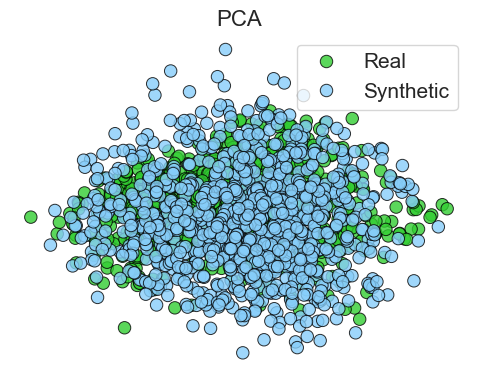

[Intrinsic Diversity] Uniqueness (NN ratio, syn/real): 1.116  (~1 ideal; <1 collapse; >1 over-dispersion)
[Intrinsic Diversity] Global Diversity (pairwise ratio, syn/real): 1.022 (~1 ideal; <1 collapse; >1 over-dispersion)
[Intrinsic Diversity] Local Diversity P10/P50 (NN ratio): 1.583 / 1.057 (~1 ideal; <1 collapse; >1 over-dispersion)
Diversity Score: 0.879


In [3]:
# Initialize class
div = Diversity()

# Compute coverage diversity metrics
cov = div.compute_coverage_diversity(real_data, synthetic_data)

# Compute geometric diversity metrics
geom = div.compute_geometric_diversity(real_data, synthetic_data)

# Plot PCA and UMAP results
div.plot_embeddings("PCA", geom)
#div.plot_embeddings("UMAP", geom)

# Compute intrinsic diversity metrics
intr = div.compute_intrinsic_diversity(real_data, synthetic_data)

# Compute diversity score
evaluation_score.compute_diversity_score(real_data, synthetic_data)

#### 5. Privacy evaluation

In [ ]:
# Initialize class
privacy_analysis = Privacy()

# Compute distance and MIR metrics
distance_metrics = privacy_analysis.compute_distance_metrics(real_data[:100], synthetic_data[:100])

# Compute privacy score
evaluation_score.compute_privacy_score(real_data[:100], synthetic_data[:100])

📏 Nearest-Neighbour distances between real and synthetic data:
    -> Signals z-scored using real data SD (L2/DTW in units of real SD per sample).
